## Import Library & Data Prep

In [1]:
import os
import json
import platform
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"tensorflow : {tf.__version__}")
print(f"seeds : {SEEDS}")

NB2_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02"
NB4A_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook04b"

features = pd.read_csv(f"{NB2_DIR}/features_gold.csv")
split = pd.read_csv(f"{NB2_DIR}/split_assignment.csv")

with open(f"{NB4A_DIR}/nb4a_selected_hparams.json") as f:
    selected_params = json.load(f)

MODEL_NAMES = ["Decision Tree", "LightGBM", "XGBoost", "TCN", "GRU", "CNN-LSTM"]

original_split = split[split.group == "original"].copy()
test_rows_indist = original_split[original_split.split == "test"]
train_rows_pool = original_split[original_split.split == "train"]
val_rows_fixed = original_split[original_split.split == "val"]

extra_paths = split.loc[split.group == "extra", "path"]
variants_paths = split.loc[split.group == "variants", "path"]
mix_paths = split.loc[split.group == "mix", "path"]

print(f"train pool : {len(train_rows_pool)} eksekusi")
print(f"val : {len(val_rows_fixed)} eksekusi")
print(f"test : {len(test_rows_indist)} eksekusi")
print(f"extra : {len(extra_paths)} eksekusi")
print(f"variants : {len(variants_paths)} eksekusi")
print(f"mix : {len(mix_paths)} eksekusi")

STORAGE_FEATURE_NAMES = ["T_s_r", "T_s_w", "V_s_r", "V_s_w", "H_s_w"]
MEMORY_FEATURE_NAMES = (
    ["H_m_w", "H_m_rw"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
ALL_FEATURE_NAMES = STORAGE_FEATURE_NAMES + MEMORY_FEATURE_NAMES
FEATURE_COLUMNS_FULL = ALL_FEATURE_NAMES + ["w"]
LOG1P_FEATURES = (
    ["T_s_r", "T_s_w", "V_s_r", "V_s_w"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
LOG1P_IDX = [FEATURE_COLUMNS_FULL.index(f) for f in LOG1P_FEATURES]


def checkpoints_for_step(step, max_w=30):
    return list(range(step, max_w + 1, step))


def build_sequences(df, paths, checkpoint_grid, feature_names):
    sub = df[df["path"].isin(paths) & df["window_s"].isin(checkpoint_grid)]
    sequences, labels = [], []
    for path, g in sub.groupby("path", sort=False):
        g = g.sort_values("window_s")
        assert len(g) == len(checkpoint_grid)
        w = g["window_s"].to_numpy(dtype="float64")
        feat = g[feature_names].to_numpy(dtype="float64")
        sequences.append(np.concatenate([feat, w[:, None]], axis=1))
        labels.append(int(g["is_ransomware"].iloc[0]))
    X = np.stack(sequences).astype("float32")
    y = np.array(labels, dtype="int32")
    return X, y


def apply_log1p(X, idx):
    X = X.copy()
    X[..., idx] = np.log1p(np.clip(X[..., idx], a_min=0.0, a_max=None))
    return X


def scale_3d(X, scaler):
    shp = X.shape
    return scaler.transform(X.reshape(-1, shp[-1])).reshape(shp).astype("float32")


def cost_sensitive_predict(p, beta):
    threshold = 1.0 / (1.0 + beta)
    return (p > threshold).astype(int)


def build_economy_table(calib_probs, calib_y, K, beta):
    n_calib, M = calib_probs.shape
    bin_edges = np.zeros((M, K - 1))
    group_idx = np.zeros((n_calib, M), dtype=int)
    for i in range(M):
        edges = np.quantile(calib_probs[:, i], np.linspace(0, 1, K + 1)[1:-1])
        bin_edges[i] = edges
        gi = np.searchsorted(edges, calib_probs[:, i], side="right")
        group_idx[:, i] = np.clip(gi, 0, K - 1)
    hard_pred = cost_sensitive_predict(calib_probs, beta)
    prior1, fp_rate, fn_rate = {}, {}, {}
    for i in range(M):
        for k in range(K):
            mask_ik = group_idx[:, i] == k
            n_ik = mask_ik.sum()
            if n_ik == 0:
                prior1[(i, k)] = 0.5
                for j in range(i, M):
                    fp_rate[(i, j, k)] = 0.5
                    fn_rate[(i, j, k)] = 0.5
                continue
            y_ik = calib_y[mask_ik]
            prior1[(i, k)] = y_ik.mean()
            benign_mask = mask_ik & (calib_y == 0)
            ransom_mask = mask_ik & (calib_y == 1)
            n_benign, n_ransom = benign_mask.sum(), ransom_mask.sum()
            for j in range(i, M):
                fp_rate[(i, j, k)] = hard_pred[benign_mask, j].mean() if n_benign > 0 else 0.5
                fn_rate[(i, j, k)] = 1.0 - hard_pred[ransom_mask, j].mean() if n_ransom > 0 else 0.5
    return bin_edges, prior1, fp_rate, fn_rate


def simulate_decisions(probs, checkpoint_grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta, T_max=30.0):
    n_samples, M = probs.shape
    y_pred = np.zeros(n_samples, dtype=int)
    decision_time = np.zeros(n_samples)
    for s in range(n_samples):
        for i in range(M):
            p_i = probs[s, i]
            k = int(np.clip(np.searchsorted(bin_edges[i], p_i, side="right"), 0, len(bin_edges[i])))
            best_tau, best_cost = 0, np.inf
            pr1 = prior1[(i, k)]
            pr0 = 1.0 - pr1
            for j in range(i, M):
                cost_now = pr0 * fp_rate[(i, j, k)] * 1.0 + pr1 * fn_rate[(i, j, k)] * beta
                cd = alpha * (checkpoint_grid[j] / T_max)
                total = cost_now + cd
                if total < best_cost:
                    best_cost, best_tau = total, j - i
            if best_tau == 0 or i == M - 1:
                y_pred[s] = 1 if p_i > (1.0 / (1.0 + beta)) else 0
                decision_time[s] = checkpoint_grid[i]
                break
    return y_pred, decision_time


def economy_objectives_fixed(probs_calib, y_calib, probs_val, y_val, checkpoint_grid, K, alpha, beta):
    bin_edges, prior1, fp_rate, fn_rate = build_economy_table(probs_calib, y_calib, K, beta)
    y_pred, dtime = simulate_decisions(probs_val, checkpoint_grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    return f1, float(dtime.mean())


def _tcn_residual_block(x, filters, kernel_size, dilation_rate):
    prev = x
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(h)
    if prev.shape[-1] != filters:
        prev = layers.Conv1D(filters, 1, padding="same")(prev)
    return layers.Add()([prev, h])


def build_tcn_hpo(seq_len, n_features, filters, kernel_size, dilations, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for d in dilations:
        x = _tcn_residual_block(x, filters, kernel_size, d)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="tcn")


def build_gru_hpo(seq_len, n_features, units, n_layers, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for _ in range(n_layers):
        x = layers.GRU(units, return_sequences=True)(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="gru")


def build_cnn_lstm_hpo(seq_len, n_features, conv_filters, kernel_size, lstm_units, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(filters=conv_filters, kernel_size=kernel_size, padding="causal", activation="linear")(inputs)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="cnn_lstm_modified")


RESULTS_PATH = "/kaggle/working/nb6_results.csv"
RESULT_COLUMNS = ["model", "seed", "scenario", "f1", "avg_time_s", "n_eval"]


def load_done_keys():
    if os.path.exists(RESULTS_PATH):
        done = pd.read_csv(RESULTS_PATH)
        return set(zip(done["model"], done["seed"]))
    return set()


def append_result(rows):
    df_new = pd.DataFrame(rows, columns=RESULT_COLUMNS)
    header = not os.path.exists(RESULTS_PATH)
    df_new.to_csv(RESULTS_PATH, mode="a", header=header, index=False)


python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3
tensorflow : 2.20.0
seeds : [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
train pool : 1007 eksekusi
val : 216 eksekusi
test : 216 eksekusi
extra : 360 eksekusi
variants : 70 eksekusi
mix : 100 eksekusi


## Training & Evaluasi

In [2]:
SCENARIOS = {
    "extra": (extra_paths, None),
    "variants": (variants_paths, None),
    "mix": (mix_paths, None),
}

done_keys = load_done_keys()
print(f"{len(done_keys)} (model, seed) sudah selesai sebelumnya.\n")

for name in MODEL_NAMES:
    params = selected_params[name]
    step = params["step"]
    grid = checkpoints_for_step(step)

    for seed in SEEDS:
        if (name, seed) in done_keys:
            print(f"[SKIP] {name} seed={seed} sudah ada di {RESULTS_PATH}")
            continue

        fit_df, calib_df = train_test_split(
            train_rows_pool, test_size=0.20, stratify=train_rows_pool["class"], random_state=seed
        )

        X_fit_raw, y_fit = build_sequences(features, fit_df["path"], grid, ALL_FEATURE_NAMES)
        X_calib_raw, y_calib = build_sequences(features, calib_df["path"], grid, ALL_FEATURE_NAMES)
        X_test_raw, y_test = build_sequences(features, test_rows_indist["path"], grid, ALL_FEATURE_NAMES)
        X_extra_raw, y_extra = build_sequences(features, extra_paths, grid, ALL_FEATURE_NAMES)
        X_variants_raw, y_variants = build_sequences(features, variants_paths, grid, ALL_FEATURE_NAMES)
        X_mix_raw, y_mix = build_sequences(features, mix_paths, grid, ALL_FEATURE_NAMES)

        X_fit_log = apply_log1p(X_fit_raw, LOG1P_IDX)
        scaler = StandardScaler().fit(X_fit_log.reshape(-1, X_fit_log.shape[-1]))

        def prep(Xraw):
            return scale_3d(apply_log1p(Xraw, LOG1P_IDX), scaler)

        X_fit = prep(X_fit_raw)
        X_calib = prep(X_calib_raw)
        X_test = prep(X_test_raw)
        X_extra = prep(X_extra_raw)
        X_variants = prep(X_variants_raw)
        X_mix = prep(X_mix_raw)

        if name in ("Decision Tree", "LightGBM", "XGBoost"):
            models_per_ckpt = []
            for i in range(len(grid)):
                if name == "Decision Tree":
                    m = DecisionTreeClassifier(random_state=seed, max_depth=params["dtree_max_depth"],
                                                min_samples_leaf=params["dtree_min_samples_leaf"])
                elif name == "LightGBM":
                    m = lgb.LGBMClassifier(random_state=seed, verbose=-1,
                                            n_estimators=params["lgbm_n_estimators"],
                                            max_depth=params["lgbm_max_depth"],
                                            learning_rate=params["lgbm_learning_rate"],
                                            num_leaves=params["lgbm_num_leaves"],
                                            subsample=params["lgbm_subsample"])
                else:
                    m = xgb.XGBClassifier(random_state=seed, eval_metric="logloss",
                                           n_estimators=params["xgb_n_estimators"],
                                           max_depth=params["xgb_max_depth"],
                                           learning_rate=params["xgb_learning_rate"],
                                           subsample=params["xgb_subsample"])
                m.fit(X_fit[:, i, :], y_fit)
                models_per_ckpt.append(m)

            def predict_all(X, _models=models_per_ckpt):
                return np.stack([m.predict_proba(X[:, i, :])[:, 1] for i, m in enumerate(_models)], axis=1)
        else:
            y_fit_seq = np.repeat(y_fit[:, None, None], len(grid), axis=1).astype("float32")
            y_calib_seq = np.repeat(y_calib[:, None, None], len(grid), axis=1).astype("float32")

            keras.utils.set_random_seed(seed)
            if name == "TCN":
                dilations = tuple(2 ** i for i in range(params["tcn_n_blocks"]))
                dl_model = build_tcn_hpo(len(grid), X_fit.shape[-1], params["tcn_filters"],
                                          params["tcn_kernel_size"], dilations, params["tcn_dropout"])
                lr = params["tcn_lr"]
            elif name == "GRU":
                dl_model = build_gru_hpo(len(grid), X_fit.shape[-1], params["gru_units"],
                                          params["gru_n_layers"], params["gru_dropout"])
                lr = params["gru_lr"]
            else:
                dl_model = build_cnn_lstm_hpo(len(grid), X_fit.shape[-1], params["cnnlstm_conv_filters"],
                                               params["cnnlstm_kernel_size"], params["cnnlstm_lstm_units"],
                                               params["cnnlstm_dropout"])
                lr = params["cnnlstm_lr"]

            dl_model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy")
            es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
            dl_model.fit(X_fit, y_fit_seq, validation_data=(X_calib, y_calib_seq),
                         epochs=50, batch_size=32, callbacks=[es], verbose=0)

            def predict_all(X, _m=dl_model):
                return _m.predict(X, verbose=0)[:, :, 0]

        probs_calib = predict_all(X_calib)
        K, alpha, beta = params["economy_K"], params["economy_alpha"], params["economy_beta"]

        rows = []
        for scen_name, Xs, ys in [
            ("in_distribution", X_test, y_test),
            ("extra", X_extra, y_extra),
            ("variants", X_variants, y_variants),
            ("mix", X_mix, y_mix),
        ]:
            probs_s = predict_all(Xs)
            f1, avg_time = economy_objectives_fixed(probs_calib, y_calib, probs_s, ys, grid, K, alpha, beta)
            rows.append([name, seed, scen_name, f1, avg_time, len(ys)])
            print(f"{name:14s} seed={seed} {scen_name:16s}: f1={f1:.4f} avg_time_s={avg_time:.3f} (n={len(ys)})")

        append_result(rows)

0 (model, seed) sudah selesai sebelumnya.

Decision Tree  seed=42 in_distribution : f1=0.9196 avg_time_s=16.574 (n=216)
Decision Tree  seed=42 extra           : f1=0.7701 avg_time_s=19.889 (n=360)
Decision Tree  seed=42 variants        : f1=0.8800 avg_time_s=24.000 (n=70)
Decision Tree  seed=42 mix             : f1=0.5507 avg_time_s=14.400 (n=100)
Decision Tree  seed=43 in_distribution : f1=0.8930 avg_time_s=24.907 (n=216)
Decision Tree  seed=43 extra           : f1=0.8328 avg_time_s=25.056 (n=360)
Decision Tree  seed=43 variants        : f1=0.9552 avg_time_s=27.571 (n=70)
Decision Tree  seed=43 mix             : f1=0.7342 avg_time_s=25.900 (n=100)
Decision Tree  seed=44 in_distribution : f1=0.8910 avg_time_s=20.694 (n=216)
Decision Tree  seed=44 extra           : f1=0.7603 avg_time_s=22.139 (n=360)
Decision Tree  seed=44 variants        : f1=0.8618 avg_time_s=24.571 (n=70)
Decision Tree  seed=44 mix             : f1=0.4375 avg_time_s=18.500 (n=100)
Decision Tree  seed=45 in_distributi

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM       seed=42 in_distribution : f1=0.9589 avg_time_s=17.292 (n=216)
LightGBM       seed=42 extra           : f1=0.8400 avg_time_s=22.389 (n=360)
LightGBM       seed=42 variants        : f1=1.0000 avg_time_s=21.286 (n=70)
LightGBM       seed=42 mix             : f1=0.7013 avg_time_s=21.250 (n=100)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM       seed=43 in_distribution : f1=0.9327 avg_time_s=14.722 (n=216)
LightGBM       seed=43 extra           : f1=0.8689 avg_time_s=18.319 (n=360)
LightGBM       seed=43 variants        : f1=1.0000 avg_time_s=17.214 (n=70)
LightGBM       seed=43 mix             : f1=0.6395 avg_time_s=17.150 (n=100)


...

LightGBM       seed=50 in_distribution : f1=0.9459 avg_time_s=15.208 (n=216)
LightGBM       seed=50 extra           : f1=0.8740 avg_time_s=19.444 (n=360)
LightGBM       seed=50 variants        : f1=1.0000 avg_time_s=20.571 (n=70)
LightGBM       seed=50 mix             : f1=0.7500 avg_time_s=20.000 (n=100)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM       seed=51 in_distribution : f1=0.9309 avg_time_s=14.699 (n=216)
LightGBM       seed=51 extra           : f1=0.8964 avg_time_s=18.653 (n=360)
LightGBM       seed=51 variants        : f1=0.9928 avg_time_s=21.857 (n=70)
LightGBM       seed=51 mix             : f1=0.5816 avg_time_s=16.100 (n=100)
XGBoost        seed=42 in_distribution : f1=0.9450 avg_time_s=14.144 (n=216)
XGBoost        seed=42 extra           : f1=0.8550 avg_time_s=20.083 (n=360)
XGBoost        seed=42 variants        : f1=1.0000 avg_time_s=20.143 (n=70)
XGBoost        seed=42 mix             : f1=0.5401 avg_time_s=13.900 (n=100)
XGBoost        seed=43 in_distribution : f1=0.9170 avg_time_s=12.940 (n=216)
XGBoost        seed=43 extra           : f1=0.8665 avg_time_s=18.000 (n=360)
XGBoost        seed=43 variants        : f1=1.0000 avg_time_s=14.357 (n=70)
XGBoost        seed=43 mix             : f1=0.8304 avg_time_s=20.100 (n=100)
XGBoost        seed=44 in_distribution : f1=0.9369 avg_time_s=14.676 (n=216)
XG

I0000 00:00:1789977275.806220      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789977275.809478      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1789977285.773912      78 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


TCN            seed=42 in_distribution : f1=0.9174 avg_time_s=30.000 (n=216)
TCN            seed=42 extra           : f1=0.8939 avg_time_s=30.000 (n=360)
TCN            seed=42 variants        : f1=1.0000 avg_time_s=30.000 (n=70)
TCN            seed=42 mix             : f1=0.7097 avg_time_s=30.000 (n=100)
TCN            seed=43 in_distribution : f1=0.8966 avg_time_s=20.185 (n=216)
TCN            seed=43 extra           : f1=0.8387 avg_time_s=19.444 (n=360)
TCN            seed=43 variants        : f1=1.0000 avg_time_s=12.857 (n=70)
TCN            seed=43 mix             : f1=0.7654 avg_time_s=22.800 (n=100)
TCN            seed=44 in_distribution : f1=0.9083 avg_time_s=24.722 (n=216)
TCN            seed=44 extra           : f1=0.8759 avg_time_s=24.222 (n=360)
TCN            seed=44 variants        : f1=1.0000 avg_time_s=20.286 (n=70)
TCN            seed=44 mix             : f1=0.8950 avg_time_s=22.000 (n=100)
TCN            seed=45 in_distribution : f1=0.9406 avg_time_s=30.000 (n=216)
TC

## Ringkasan Hasil & Visualisasi

### 1. Setup & konfigurasi

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RESULTS_PATH = "/kaggle/working/nb6_results.csv"

FIG_DIR = "/kaggle/working/figures" if os.path.isdir("/kaggle/working") else "figures"
os.makedirs(FIG_DIR, exist_ok=True)

MODEL_ORDER_ALL = ["Decision Tree", "LightGBM", "XGBoost", "TCN", "GRU", "CNN-LSTM"]
SEEDS = [42, 43, 44, 45, 46]
SCENARIOS = ["in_distribution", "extra", "variants", "mix"]
SCEN_LABEL = {"in_distribution": "In-distribution", "extra": "Extra",
              "variants": "Variants", "mix": "Mix"}
T_MAX = 30.0 

COLORS = {"Decision Tree": "#8C8C8C", "LightGBM": "#009E73", "XGBoost": "#E69F00",
          "TCN": "#0072B2", "GRU": "#CC79A7", "CNN-LSTM": "#D55E00"}

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True, "legend.frameon": False,
})

def save_fig(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

### 2. Muat data & cek kelengkapan

In [4]:
df = pd.read_csv(RESULTS_PATH).drop_duplicates(["model", "seed", "scenario"], keep="last")
MODELS = [m for m in MODEL_ORDER_ALL if m in set(df["model"])]

expected_rows = len(MODEL_ORDER_ALL) * len(SEEDS) * len(SCENARIOS)
print(f"Sumber : {RESULTS_PATH}")
print(f"Baris  : {len(df)} dari {expected_rows} yang diharapkan "
      f"({len(MODEL_ORDER_ALL)} model x {len(SEEDS)} seed x {len(SCENARIOS)} skenario)\n")

seeds_done = (df.groupby("model")["seed"].nunique()
                .reindex(MODEL_ORDER_ALL).fillna(0).astype(int))
for m, n in seeds_done.items():
    status = "lengkap" if n == len(SEEDS) else ("BELUM LENGKAP" if n else "TIDAK ADA DI CSV")
    print(f"  {m:14s} {n}/{len(SEEDS)} seed  -> {status}")

Sumber : /kaggle/working/nb6_results.csv
Baris  : 240 dari 120 yang diharapkan (6 model x 5 seed x 4 skenario)

  Decision Tree  10/5 seed  -> BELUM LENGKAP
  LightGBM       10/5 seed  -> BELUM LENGKAP
  XGBoost        10/5 seed  -> BELUM LENGKAP
  TCN            10/5 seed  -> BELUM LENGKAP
  GRU            10/5 seed  -> BELUM LENGKAP
  CNN-LSTM       10/5 seed  -> BELUM LENGKAP


### 3. Tabel ringkasan (rata-rata ± std antar seed)

In [5]:
agg = (df.groupby(["model", "scenario"])
         .agg(f1_mean=("f1", "mean"), f1_std=("f1", "std"),
              t_mean=("avg_time_s", "mean"), t_std=("avg_time_s", "std"),
              n_seed=("seed", "nunique"))
         .reset_index())
agg[["f1_std", "t_std"]] = agg[["f1_std", "t_std"]].fillna(0)


def pv(col):
    return agg.pivot(index="model", columns="scenario", values=col).reindex(index=MODELS, columns=SCENARIOS)


def show_table(mean_col, std_col, digits, best, title):
    mean = pv(mean_col).rename(columns=SCEN_LABEL)
    std = pv(std_col).rename(columns=SCEN_LABEL)
    text = mean.apply(lambda c: c.map(f"{{:.{digits}f}}".format)) + " ± " + \
           std.apply(lambda c: c.map(f"{{:.{digits}f}}".format))
    best_idx = mean.idxmax(axis=0) if best == "max" else mean.idxmin(axis=0)

    def highlight(col):
        return ["font-weight:bold; background-color:#d4edda" if i == best_idx[col.name] else ""
                for i in col.index]

    display(text.style.apply(highlight, axis=0).set_caption(title))


show_table("f1_mean", "f1_std", 3, "max", "F1-score (lebih tinggi lebih baik)")
show_table("t_mean", "t_std", 1, "min", "Rata-rata waktu keputusan, detik (lebih rendah lebih baik)")

print("Jumlah seed per model:", agg.groupby("model")["n_seed"].max().reindex(MODELS).to_dict())
agg.to_csv(f"{FIG_DIR}/summary_table.csv", index=False)

scenario,In-distribution,Extra,Variants,Mix
model,,,,
Decision Tree,0.915 ± 0.015,0.792 ± 0.025,0.948 ± 0.042,0.690 ± 0.157
LightGBM,0.942 ± 0.011,0.876 ± 0.019,0.995 ± 0.010,0.659 ± 0.078
XGBoost,0.938 ± 0.014,0.882 ± 0.027,0.994 ± 0.005,0.677 ± 0.087
TCN,0.900 ± 0.032,0.870 ± 0.029,0.997 ± 0.005,0.773 ± 0.076
GRU,0.851 ± 0.039,0.789 ± 0.034,0.993 ± 0.009,0.696 ± 0.116
CNN-LSTM,0.919 ± 0.017,0.857 ± 0.026,0.928 ± 0.086,0.460 ± 0.084


scenario,In-distribution,Extra,Variants,Mix
model,,,,
Decision Tree,24.3 ± 4.2,25.8 ± 3.0,26.1 ± 2.6,25.5 ± 5.1
LightGBM,16.3 ± 1.7,20.2 ± 1.5,20.9 ± 1.8,19.1 ± 3.1
XGBoost,14.4 ± 1.7,19.0 ± 1.5,19.4 ± 2.5,19.5 ± 3.6
TCN,25.5 ± 4.9,25.2 ± 5.3,22.6 ± 8.3,26.1 ± 4.2
GRU,12.3 ± 1.4,12.2 ± 1.7,10.0 ± 1.9,12.3 ± 1.9
CNN-LSTM,16.2 ± 2.7,18.0 ± 3.0,18.6 ± 3.5,15.6 ± 3.1


Jumlah seed per model: {'Decision Tree': 10, 'LightGBM': 10, 'XGBoost': 10, 'TCN': 10, 'GRU': 10, 'CNN-LSTM': 10}


### 4. F1-score per skenario

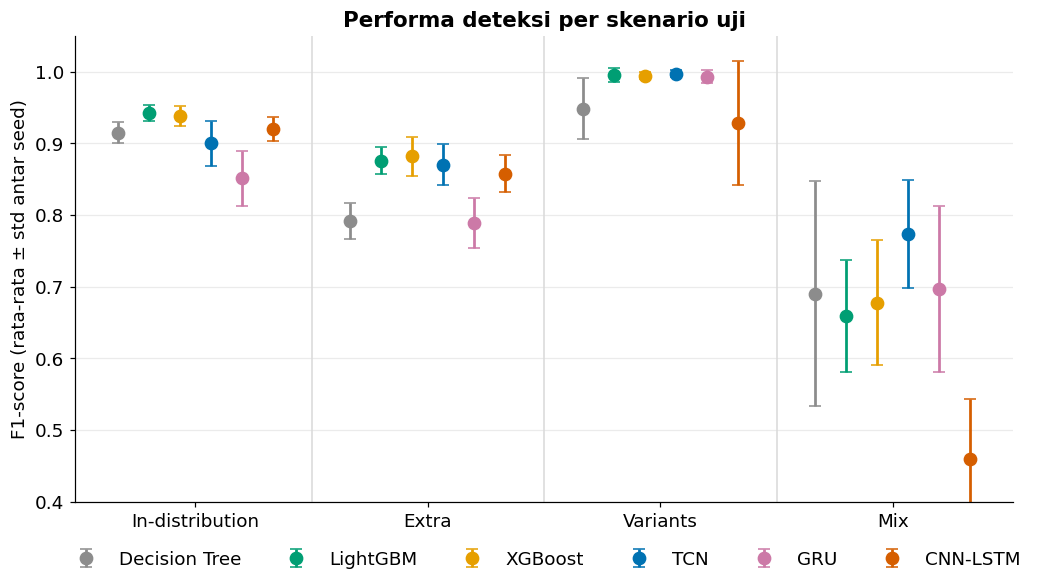

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(SCENARIOS))
width = 0.8 / len(MODELS)

for k, m in enumerate(MODELS):
    sub = agg[agg["model"] == m].set_index("scenario").reindex(SCENARIOS)
    pos = x - 0.4 + width * (k + 0.5)
    ax.errorbar(pos, sub["f1_mean"], yerr=sub["f1_std"], fmt="o", ms=8, capsize=4, lw=1.8,
                color=COLORS[m], label=m)

for b in x[:-1] + 0.5:
    ax.axvline(b, color="0.85", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([SCEN_LABEL[s] for s in SCENARIOS])
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("F1-score (rata-rata ± std antar seed)")
ax.set_title("Performa deteksi per skenario uji")
ax.grid(axis="x", visible=False)
ax.legend(ncol=len(MODELS), loc="upper center", bbox_to_anchor=(0.5, -0.07))
save_fig(fig, "01_f1_per_skenario")

### 5. Heatmap F1: model × skenario

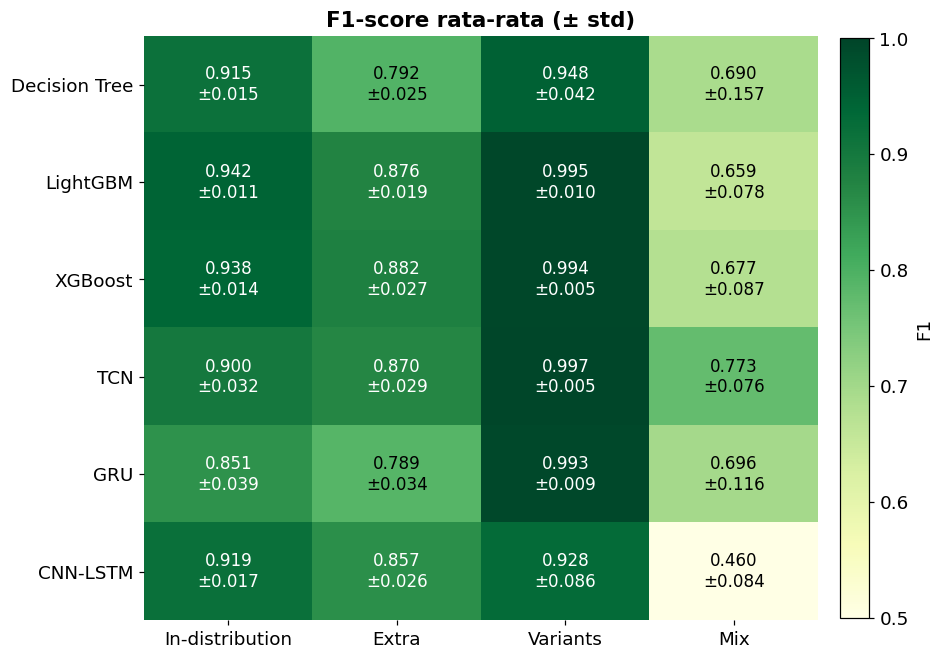

In [7]:
mean, std = pv("f1_mean"), pv("f1_std")

fig, ax = plt.subplots(figsize=(8.5, 0.85 * len(MODELS) + 1.8))
im = ax.imshow(mean.values, cmap="YlGn", vmin=0.5, vmax=1.0, aspect="auto")

for i in range(len(MODELS)):
    for j in range(len(SCENARIOS)):
        v, s = mean.values[i, j], std.values[i, j]
        if np.isnan(v):
            ax.text(j, i, "-", ha="center", va="center", color="0.5")
        else:
            r, g, b, _ = im.cmap(im.norm(v))
            lum = 0.299 * r + 0.587 * g + 0.114 * b
            ax.text(j, i, f"{v:.3f}\n±{s:.3f}", ha="center", va="center", fontsize=11,
                    color="white" if lum < 0.5 else "black")

ax.set_xticks(range(len(SCENARIOS)))
ax.set_xticklabels([SCEN_LABEL[s] for s in SCENARIOS])
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels(MODELS)
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_title("F1-score rata-rata (± std)")
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label="F1")
save_fig(fig, "02_heatmap_f1")

### 6. Trade-off: akurasi vs kecepatan keputusan

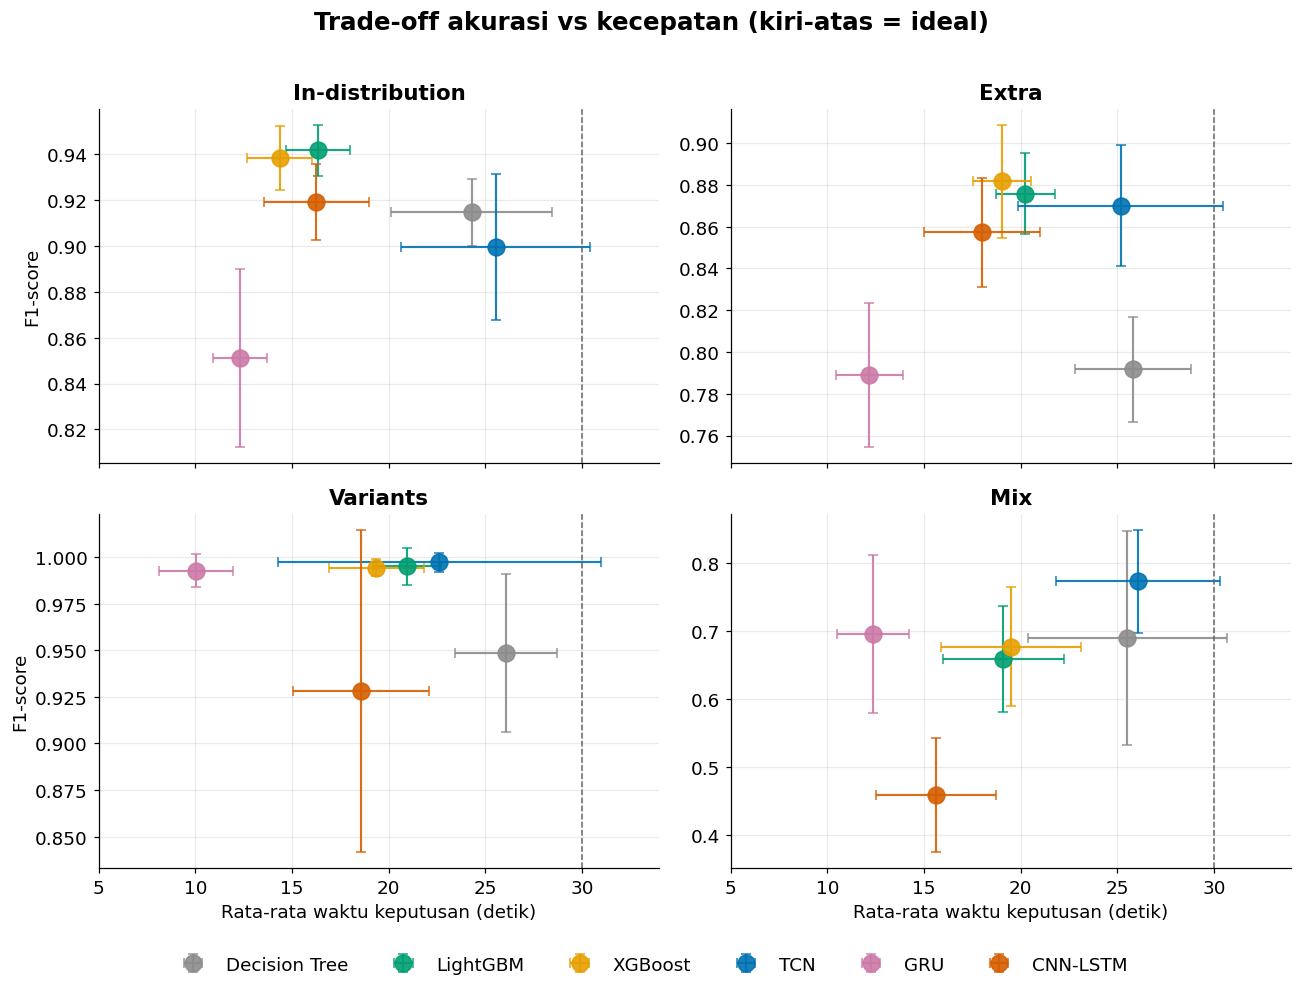

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

for ax, s in zip(axes.ravel(), SCENARIOS):
    sub = agg[agg["scenario"] == s].set_index("model").reindex(MODELS).dropna(subset=["f1_mean"])
    for m, r in sub.iterrows():
        ax.errorbar(r["t_mean"], r["f1_mean"], xerr=r["t_std"], yerr=r["f1_std"],
                    fmt="o", ms=11, capsize=3, lw=1.4, alpha=0.9,
                    color=COLORS[m], label=m)
    ax.axvline(T_MAX, ls="--", color="0.4", lw=1)
    ax.set_title(SCEN_LABEL[s])
    ax.set_xlim(5, 34)

for ax in axes[1]:
    ax.set_xlabel("Rata-rata waktu keputusan (detik)")
for ax in axes[:, 0]:
    ax.set_ylabel("F1-score")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(MODELS), loc="lower center", bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Trade-off akurasi vs kecepatan (kiri-atas = ideal)", fontsize=16, fontweight="bold")
fig.tight_layout(rect=(0, 0.04, 1, 0.97))
save_fig(fig, "03_tradeoff_f1_vs_waktu")

### 7. Stabilitas antar seed

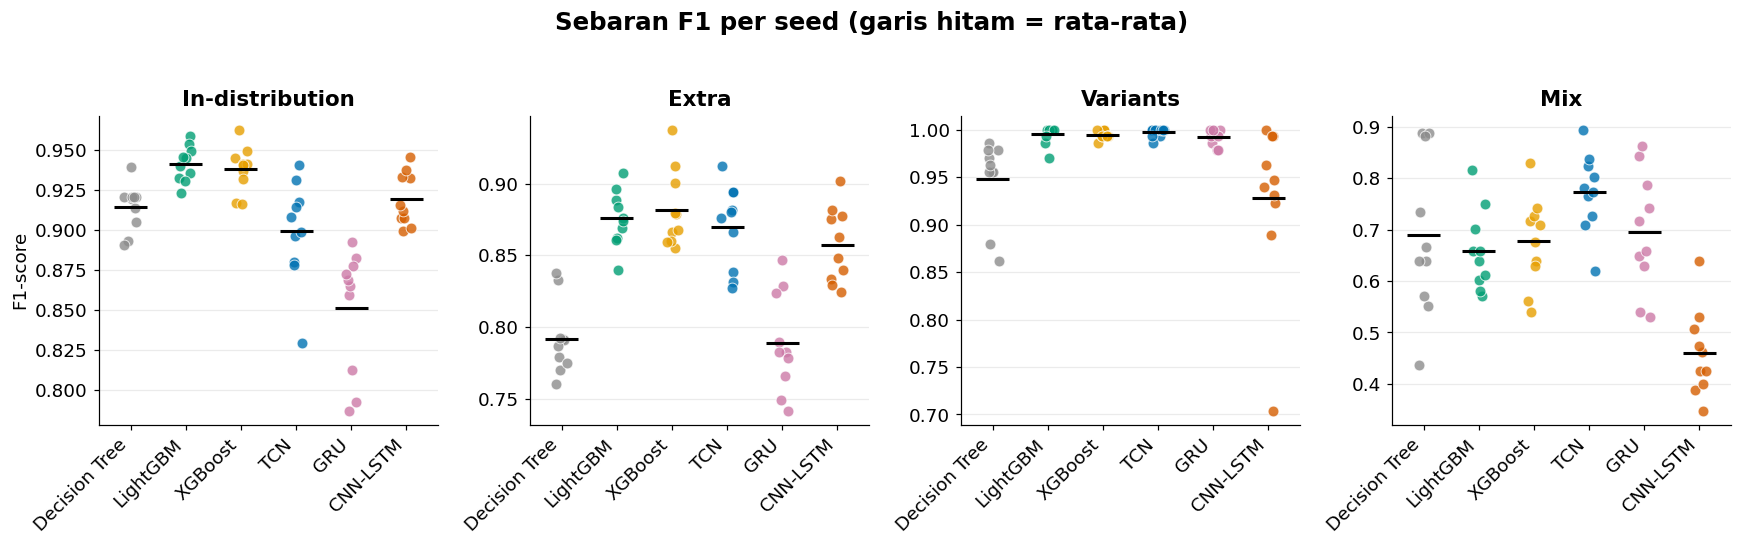

In [9]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(16, 4.8))

for ax, s in zip(axes, SCENARIOS):
    for k, m in enumerate(MODELS):
        v = df[(df["model"] == m) & (df["scenario"] == s)]["f1"].to_numpy()
        if len(v) == 0:
            continue
        ax.scatter(k + rng.uniform(-0.12, 0.12, len(v)), v, s=50, color=COLORS[m],
                   alpha=0.8, edgecolor="white", linewidth=0.6, zorder=3)
        ax.hlines(v.mean(), k - 0.3, k + 0.3, color="black", lw=2, zorder=4)
    ax.set_xticks(range(len(MODELS)))
    ax.set_xticklabels(MODELS, rotation=45, ha="right")
    ax.set_title(SCEN_LABEL[s])
    ax.grid(axis="x", visible=False)

axes[0].set_ylabel("F1-score")
fig.suptitle("Sebaran F1 per seed (garis hitam = rata-rata)", fontsize=16, fontweight="bold", y=1.03)
fig.tight_layout()
save_fig(fig, "04_stabilitas_seed")

### 8. Waktu keputusan

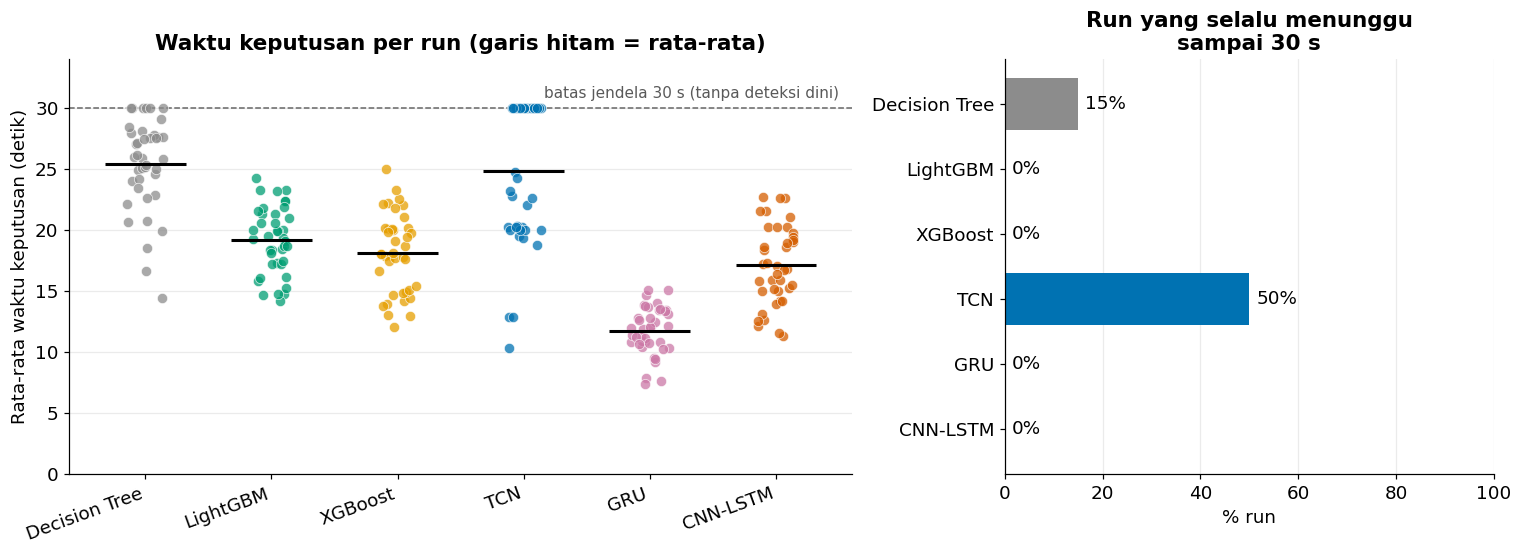

In [10]:
rng = np.random.default_rng(1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.6, 1]})

for k, m in enumerate(MODELS):
    v = df[df["model"] == m]["avg_time_s"].to_numpy()
    ax1.scatter(k + rng.uniform(-0.15, 0.15, len(v)), v, s=45, color=COLORS[m],
                alpha=0.75, edgecolor="white", linewidth=0.5, zorder=3)
    ax1.hlines(v.mean(), k - 0.32, k + 0.32, color="black", lw=2, zorder=4)

ax1.axhline(T_MAX, ls="--", color="0.4", lw=1)
ax1.text(len(MODELS) - 0.5, T_MAX + 0.6, "batas jendela 30 s (tanpa deteksi dini)",
         ha="right", va="bottom", fontsize=10, color="0.35")
ax1.set_xticks(range(len(MODELS)))
ax1.set_xticklabels(MODELS, rotation=20, ha="right")
ax1.set_ylim(0, 34)
ax1.set_ylabel("Rata-rata waktu keputusan (detik)")
ax1.set_title("Waktu keputusan per run (garis hitam = rata-rata)")
ax1.grid(axis="x", visible=False)

stuck = (df.assign(stuck=df["avg_time_s"] >= T_MAX - 0.01)
           .groupby("model")["stuck"].mean().reindex(MODELS) * 100)
ax2.barh(MODELS, stuck.values, color=[COLORS[m] for m in MODELS])
ax2.invert_yaxis()
ax2.set_xlim(0, 100)
for i, v in enumerate(stuck.values):
    ax2.text(v + 1.5, i, f"{v:.0f}%", va="center")
ax2.set_xlabel("% run")
ax2.set_title("Run yang selalu menunggu\nsampai 30 s")
ax2.grid(axis="y", visible=False)

fig.tight_layout()
save_fig(fig, "05_waktu_keputusan")